# Stroke Prediction using CatBoost

### Sections in this Notebook:

**1. Loading Dependencies and Data**

**2. Data Visualization and Feature Selection**

**3. Model Evaluation**

## 1. Loading Dependencies and Data

In [1]:
import numpy as np
import pandas as pd
import os
import re
import warnings

In [2]:
train=pd.read_csv("/kaggle/input/stroke-prediction-dataset/healthcare-dataset-stroke-data.csv")
train

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


## 2. Data Visualization and Feature Selection

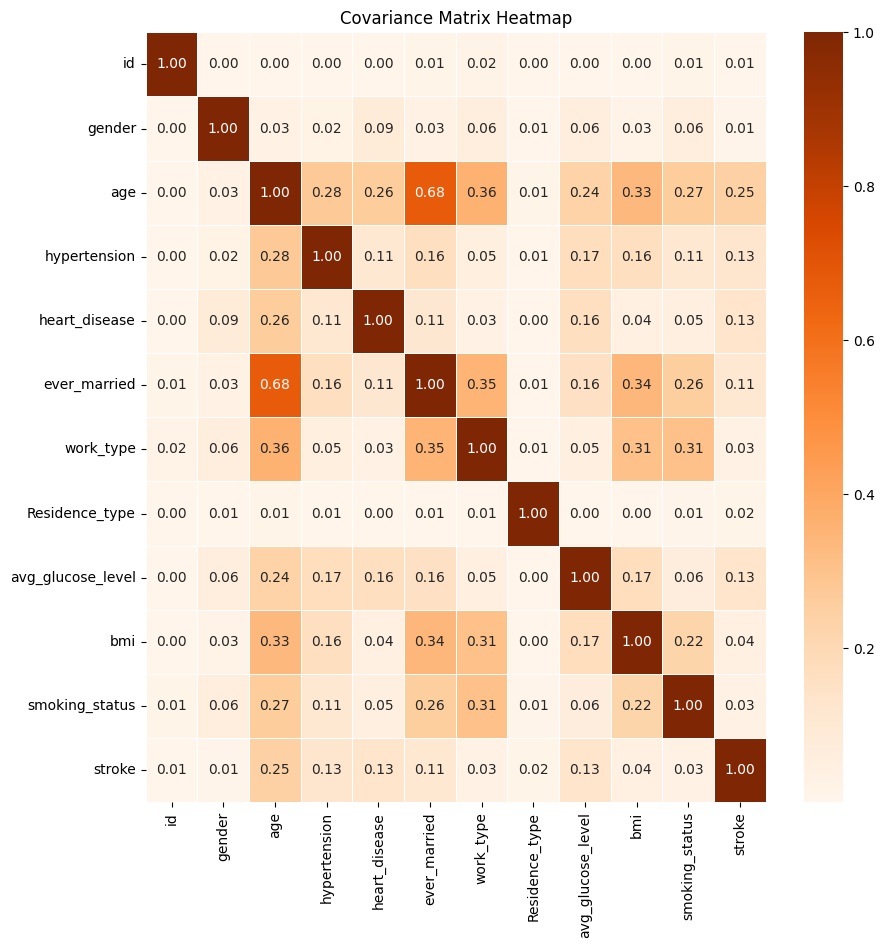

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
label_encoder = LabelEncoder()
scaler= StandardScaler()
df = train.apply(lambda x: label_encoder.fit_transform(x) if x.dtype == 'O' else x)
trainup = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)
cov_matrix = abs(trainup.cov())
plt.figure(figsize=(10, 10))
sns.heatmap(cov_matrix, annot=True, cmap='Oranges', fmt='.2f', linewidths=.5)
plt.title('Covariance Matrix Heatmap')
plt.show()

In [4]:
df=df.drop([ 'id', 'gender' ], axis=1)
X_train=df.drop(['stroke'], axis=1)
Y_train=df['stroke']
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)

## 3. Model Fitting and Evaluation

In [5]:
from catboost import CatBoostClassifier
from sklearn.model_selection import KFold, cross_val_score
model = CatBoostClassifier(iterations=100, depth=5, learning_rate=0.2, loss_function='Logloss', eval_metric='Accuracy', random_seed=42, metric_period=100) 
kf = KFold(n_splits=4, shuffle=True, random_state=42)
cv_results = cross_val_score(model, X_train, Y_train, cv=kf, scoring='accuracy')
accuracy = cv_results
average_accuracy = cv_results.mean()

print("Accuracy for each fold:", accuracy)
print("Average Accuracy across all folds:", average_accuracy)

0:	learn: 0.9558977	total: 56.3ms	remaining: 5.57s
99:	learn: 0.9605950	total: 167ms	remaining: 0us
0:	learn: 0.9478079	total: 1.63ms	remaining: 161ms
99:	learn: 0.9538100	total: 111ms	remaining: 0us
0:	learn: 0.9493869	total: 1.42ms	remaining: 141ms
99:	learn: 0.9572137	total: 104ms	remaining: 0us
0:	learn: 0.9519958	total: 1.42ms	remaining: 141ms
99:	learn: 0.9606053	total: 105ms	remaining: 0us
Accuracy for each fold: [0.94053208 0.96322379 0.95536413 0.94909945]
Average Accuracy across all folds: 0.9520548637688832
